# Partition Generator
**Purpose:** Given a large playlist, partition into k smaller playlists by clustering on features. 

**Features:** BPM, Valence, Dance, Energy, Acoustic, Album Year, Popularity

**Steps:** 
1. Select k clusters
2. Get partition params
3. Partition using best k and params

## Import Libraries

In [1]:
# Import necessary libraries for cluster analysis and visualization
import numpy as np 
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import math
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score, silhouette_samples
from itertools import combinations

## Read Data

In [2]:
df_playlist = pd.read_csv('../data/music_library.csv')
df_playlist

,Song,Artist,BPM,Camelot,Energy,Added At,Duration,Popularity,Genres,Album,...,Valence,Speech,Live,Loud (Db),Key,Time Signature,Spotify Track Id,ISRC,Playlist,Album Year
0,#1,Nelly,180,9B,59,2026-03-10,03:18,57,NaN,Nellyville,...,46,30,50,-6,G Major,4,7rSj5gEdN5KgHwbnEVAZ4b,USUR10200366,Rap RnB,2002
1,#88,Lo-Fang,135,9B,34,2026-03-16,05:48,0,NaN,#88,...,40,0,0,-10,G Major,4,1jjwFHRnfgBTJ049RJz8CQ,GBAFL2000240,Alternative,2013
2,&Run,Sir Sly,92,7B,66,2026-03-02,03:46,61,NaN,"Don't You Worry, Honey",...,48,0,10,-8,F Major,4,0w4m3Xp4svlIoyL94Zjlyd,USUM71704895,Liked Songs,2017
3,(I Can't Get No) Satisfaction - Mono,The Rolling Stones,136,10B,86,2026-03-16,03:42,74,"classic rock, rock",Out Of Our Heads,...,93,0,10,-8,D Major,4,2PzU4IB8Dr6mxV3lHuaG34,USA176510160,Rock,1965
4,(If You're Not In It For Love) I'm Outta Here!,Shania Twain,120,7B,76,2026-03-11,04:30,54,country,The Woman In Me,...,87,0,0,-8,F Major,4,6Lst3nF4McKOTLSLuTvLhw,USPR39402724,Pop,1995
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2304,wet dreams,Artemas,126,9B,72,2026-04-05,01:39,69,NaN,yustyna,...,4,0,20,-6,G Major,4,6Q57LMIIjmbOBkvXe8ADW4,QZJ842401770,Liked Songs,2024
2305,wish you were gay,Billie Eilish,118,9B,35,2026-04-05,03:41,75,NaN,"WHEN WE ALL FALL ASLEEP, WHERE DO WE GO?",...,28,20,70,-10,G Major,4,3Fj47GNK2kUF0uaEDgXLaD,USUM71900767,Liked Songs,2019
2306,you should see me in a crown,Billie Eilish,150,12B,53,2026-03-02,03:00,77,NaN,"WHEN WE ALL FALL ASLEEP, WHERE DO WE GO?",...,32,10,10,-10,E Major,4,3XF5xLJHOQQRbWya6hBp7d,USUM71810049,Liked Songs,2019
2307,you've been a bad girl,Artemas,137,9A,87,2026-03-30,02:23,61,NaN,yustyna,...,37,0,10,-2,E Minor,4,6Gron8VFcNPwj7ZamJe7Pt,QZJ842401766,Liked Songs,2024


## Environment Variables

In [3]:
# === CONFIG ===
METADATA = ['Spotify Track Id', 'Song', 'Artist', 'Album', 'Playlist']
FEATURES = ['BPM', 'Dance', 'Energy', 'Valence', 'Album Year', 'Popularity']
FEATURE_WEIGHTS = {'Valence': 3, 'Dance': 2}
TARGET_MIN = 40 # smallest playlist size 
TARGET_MAX = 60 # largest playlist size

# === N CLUSTERS ===
n_songs = len(df_playlist)
k_min = n_songs // TARGET_MAX  
k_max = n_songs // TARGET_MIN 
k_range = range(k_min, k_max + 1)

# === PREPARE DATA ===
df_playlist['Album Year'] = df_playlist['Album Date'].str[:4].astype(int)
df_playlist_features = df_playlist[FEATURES]
df_playlist_metadata = df_playlist[METADATA + ['Album Year']]
df_playlist_results = df_playlist[METADATA + ['Album Year'] + FEATURES]

# Verify
print(f"Songs: {len(df_playlist)}")
print(f"Metadata: {METADATA}")
print(f"Features: {FEATURES}")
print(f"Feature weights: {FEATURE_WEIGHTS}")
print(f"\nMissing features: {df_playlist[FEATURES].isna().sum().sum()}")
print(f"\nTarget playlist size: {TARGET_MIN}-{TARGET_MAX} songs")
print(f"k range: {k_min} to {k_max}")


Songs: 2309
Metadata: ['Spotify Track Id', 'Song', 'Artist', 'Album', 'Playlist']
Features: ['BPM', 'Dance', 'Energy', 'Valence', 'Album Year', 'Popularity']
Feature weights: {'Valence': 3, 'Dance': 2}

Missing features: 0

Target playlist size: 40-60 songs
k range: 38 to 57


## Partition Playlist

### Step 1: Pick K Clusters

In [4]:
## == HELPER FUNCTIONS ===

def evaluate_k_range(df_playlist_features, k_range, feature_weights=None, feature_names=None):
    """
    Evaluate clustering quality across a range of k values.
    
    Returns:
        DataFrame with k, silhouette for each k
    """
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(df_playlist_features)
    
    if feature_weights and feature_names:
        for feat, weight in feature_weights.items():
            if feat in feature_names:
                idx = feature_names.index(feat)
                X_scaled[:, idx] *= weight
    
    results = []
    for k in k_range:
        kmeans = KMeans(n_clusters=k, random_state=42, n_init=20)
        labels = kmeans.fit_predict(X_scaled)
        sil = silhouette_score(X_scaled, labels)
        results.append({'k': k, 'silhouette': sil})
        
    return pd.DataFrame(results)


def plot_silhouette(eval_df, n_songs):
    """Plot silhouette scores with avg playlist size on secondary axis."""
    fig, ax = plt.subplots(figsize=(10, 5))
    
    ax.plot(eval_df['k'], eval_df['silhouette'], 'go-')
    ax.set_xlabel('Number of Clusters (k)')
    ax.set_ylabel('Silhouette Score')
    ax.set_title('Silhouette by Cluster Count')
    ax.grid(alpha=0.3)
    
    # Mark best
    best_k = eval_df.loc[eval_df['silhouette'].idxmax(), 'k']
    best_sil = eval_df['silhouette'].max()
    avg_size = n_songs / best_k
    ax.axvline(x=best_k, color='r', linestyle='--', alpha=0.5)
    ax.annotate(f'Best: k={best_k}\n~{avg_size:.0f} songs/playlist\n(sil={best_sil:.3f})', 
            xy=(best_k, best_sil), 
            xytext=(1.1, 0.9),  # upper right in axes coordinates
            textcoords='axes fraction',
            fontsize=9,
            ha='left',
            arrowprops=dict(arrowstyle='->', color='gray', alpha=0.5))
    
    # Secondary x-axis for playlist size
    ax2 = ax.twiny()
    ax2.set_xlim(ax.get_xlim())
    tick_ks = ax.get_xticks()
    ax2.set_xticks(tick_ks)
    ax2.set_xticklabels([f'{n_songs/k:.0f}' if k > 0 else '' for k in tick_ks])
    ax2.set_xlabel('Avg Playlist Size')
    
    plt.tight_layout()
    plt.show()
    
    return best_k

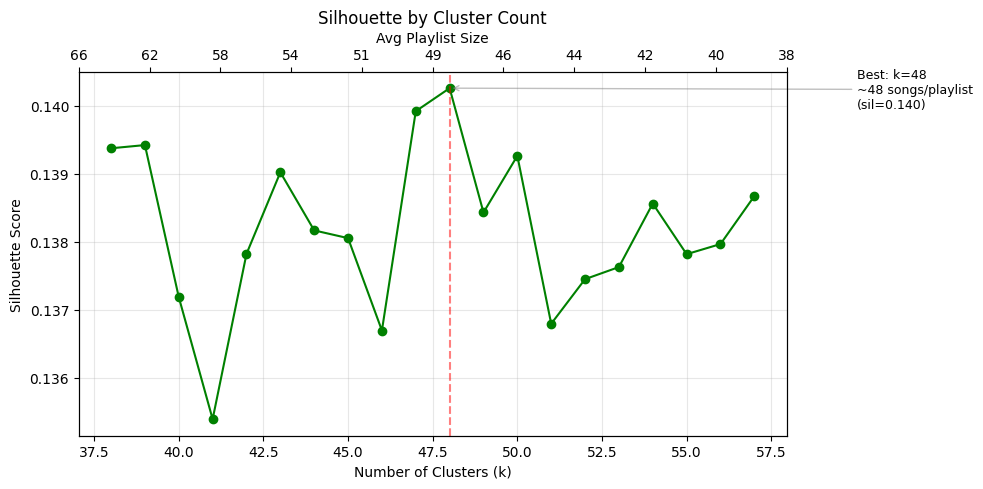


Top 5 by silhouette:
 k  avg_playlist_size  silhouette
48               48.1    0.140260
47               49.1    0.139920
39               59.2    0.139422
38               60.8    0.139375
50               46.2    0.139264


In [5]:
# === RUN EVALUATION ===
eval_df = evaluate_k_range(df_playlist_features, k_range, feature_weights=FEATURE_WEIGHTS, feature_names=FEATURES)
eval_df['avg_playlist_size'] = (n_songs / eval_df['k']).round(1)

best_k = plot_silhouette(eval_df, n_songs)

print(f"\nTop 5 by silhouette:")
print(eval_df.nlargest(5, 'silhouette')[['k', 'avg_playlist_size', 'silhouette']].to_string(index=False))

### Step 2: Get partition params

In [6]:
def get_partition_params(n_songs, best_k, tolerance=0.2):
    """
    Get min/max cluster sizes for a specific k with ±tolerance band.
    """
    avg_size = n_songs / best_k
    min_size = math.floor(avg_size * (1 - tolerance))
    max_size = math.ceil(avg_size * (1 + tolerance))
    
    print(f"Clusters: {best_k}")
    print(f"Avg size: {avg_size:.1f} songs")
    print(f"Allowed range: {min_size}-{max_size} songs (±{tolerance:.0%})")
    
    return min_size, max_size

# Get min and max size for best k
min_size, max_size = get_partition_params(n_songs, best_k, tolerance=0.2)

Clusters: 48
Avg size: 48.1 songs
Allowed range: 38-58 songs (±20%)


#### Step 3: Partition using best k and params

In [7]:
def partition_playlist(
    df_playlist_features,
    k_clusters,
    min_size,
    max_size,
    feature_weights=None
):
    """
    Partition into balanced clusters using pre-scaled data.
    """
    # Get column names from the actual DataFrame
    feature_names = list(df_playlist_features.columns)
    
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(df_playlist_features)
    X = X_scaled.copy()
    
    # --- Apply feature weights ---
    if feature_weights:
        for feature, weight in feature_weights.items():
            if feature in feature_names:
                idx = feature_names.index(feature)
                X[:, idx] *= weight
    
    # --- Cluster in scaled space ---
    kmeans = KMeans(n_clusters=k_clusters, random_state=42, n_init=50)
    initial_clusters = kmeans.fit_predict(X)
    distances = kmeans.transform(X)
    
    # --- Balance clusters ---
    clusters, n_iterations = _balance_clusters(
        initial_clusters, distances, min_size, max_size
    )
    
    # --- Print results ---
    cluster_counts = pd.Series(clusters).value_counts().sort_index()
    print(f"\nBalanced in {n_iterations} iterations")
    print(f"\nCLUSTER SIZES")
    print("=" * 50)
    print(f"Min: {cluster_counts.min()}, Max: {cluster_counts.max()}, "
          f"Mean: {cluster_counts.mean():.1f}")
    print(f"\nAll clusters in [{min_size}, {max_size}]: "
          f"{(cluster_counts >= min_size).all() and (cluster_counts <= max_size).all()}")
    print(f"\n{cluster_counts.to_string()}")
    
    return {
        'kmeans': kmeans,
        'initial_clusters': initial_clusters,
        'clusters': clusters,
        'n_clusters': k_clusters,
        'cluster_counts': cluster_counts
    }


def _balance_clusters(clusters, distances, min_size, max_size, max_iterations=500):
    """Redistribute points to balance cluster sizes."""
    clusters = clusters.copy()
    k_clusters = distances.shape[1]

    for iteration in range(max_iterations):
        counts = np.bincount(clusters, minlength=k_clusters)

        if counts.min() >= min_size and counts.max() <= max_size:
            return clusters, iteration

        biggest = np.argmax(counts)
        smallest = np.argmin(counts)

        if counts[biggest] > max_size:
            in_biggest = np.where(clusters == biggest)[0]
            dist_to_current = distances[in_biggest, biggest]
            most_distant_idx = in_biggest[np.argmax(dist_to_current)]

            point_distances = distances[most_distant_idx]
            sorted_clusters = np.argsort(point_distances)
            for next_cluster in sorted_clusters:
                if next_cluster != biggest and counts[next_cluster] < max_size:
                    clusters[most_distant_idx] = next_cluster
                    break

        elif counts[smallest] < min_size:
            not_in_smallest = np.where(clusters != smallest)[0]
            dist_to_smallest = distances[not_in_smallest, smallest]

            sorted_indices = np.argsort(dist_to_smallest)
            for idx in sorted_indices:
                point_idx = not_in_smallest[idx]
                current_cluster = clusters[point_idx]
                if counts[current_cluster] > min_size:
                    clusters[point_idx] = smallest
                    break

    print(f"Warning: Could not fully balance after {max_iterations} iterations")
    return clusters, max_iterations


In [8]:
# Get results
results = partition_playlist(df_playlist_features,
                             k_clusters=best_k,
                             min_size=min_size, 
                             max_size=max_size, 
                             feature_weights=FEATURE_WEIGHTS
                             )

# Add cluster labels to results and plot
df_playlist_results['Cluster'] = results['clusters']

# Create dictionary of playlists
playlists_spotify_api = {
    f"Playlist_{i+1}": df_playlist_results[df_playlist_results['Cluster'] == i]
        .sort_values(['BPM', 'Valence', 'Dance']).reset_index(drop=True)
        .assign(Track=lambda df: range(1, len(df) + 1))
    for i in range(results['n_clusters'])
}

# Create dataframe from playlists
df_playlists_spotify_api = pd.concat(playlists_spotify_api.values(), ignore_index=True)
df_playlists_spotify_api = df_playlists_spotify_api.loc[:, ~df_playlists_spotify_api.columns.duplicated()]
# df_playlists_spotify_api.to_csv('../results/playlists_spotify_api.csv', index=False)

df_playlists_spotify_api



Balanced in 227 iterations

CLUSTER SIZES
Min: 38, Max: 58, Mean: 48.1

All clusters in [38, 58]: True

0     46
1     54
2     38
3     40
4     49
5     58
6     52
7     58
8     42
9     38
10    58
11    58
12    56
13    38
14    41
15    55
16    58
17    38
18    58
19    38
20    52
21    58
22    49
23    58
24    52
25    45
26    55
27    57
28    38
29    54
30    38
31    42
32    48
33    38
34    58
35    38
36    38
37    57
38    38
39    54
40    38
41    44
42    58
43    38
44    40
45    38
46    55
47    58


,Spotify Track Id,Song,Artist,Album,Playlist,Album Year,BPM,Dance,Energy,Valence,Popularity,Cluster,Track
0,2K7xn816oNHJZ0aVqdQsha,Softcore,The Neighbourhood,Hard To Imagine The Neighbourhood Ever Changing,Liked Songs,2018,94,57,57,37,87,0,1
1,4CbNiKt4MugG8a7eWnRID4,Do You Think I'm Pretty,Racing Mount Pleasant,"Grip Your Fist, I'm Heaven Bound",Liked Songs,2022,108,55,32,32,55,0,2
2,3uwnnTQcHM1rDqSfA4gQNz,Cool for the Summer,Demi Lovato,Confident,Liked Songs,2015,114,58,61,34,85,0,3
3,5W4FHsvv4PwqC5gYzXyrLI,"I Love You, I'm Sorry",Gracie Abrams,The Secret of Us (Deluxe),Liked Songs,2024,116,50,40,34,60,0,4
4,113xf7t4qNM7038YJvauik,Nervous,The Neighbourhood,Hard To Imagine The Neighbourhood Ever Changing,Liked Songs,2018,120,59,61,32,78,0,5
...,...,...,...,...,...,...,...,...,...,...,...,...,...
2304,2YpeDb67231RjR0MgVLzsG,Old Town Road (feat. Billy Ray Cyrus) - Remix,"Lil Nas X,Billy Ray Cyrus",7,Rap RnB,2019,136,88,62,64,78,47,54
2305,0GxaxtdUdsUK869XGj0X7B,All Your Gold,Bat For Lashes,The Haunted Man,Liked Songs,2012,136,83,54,76,39,47,55
2306,241U1Sp7Uzh7o8T0Vr5KFF,We Belong Together,Mariah Carey,The Emancipation Of Mimi (20th Anniversary Edi...,Pop,2005,140,84,46,76,38,47,56
2307,7bcy34fBT2ap1L4bfPsl9q,I Didn't Change My Number,Billie Eilish,Happier Than Ever,Liked Songs,2021,142,85,48,68,74,47,57


In [9]:
# Print cluster feature profiles
print("=" * 50)
print("CLUSTER FEATURE PROFILES")
print("=" * 50)
def get_series(df, col_name):
    """Extract a clean numeric Series, handling duplicate columns."""
    col = df.loc[:, col_name]
    ser = col.iloc[:, 0] if isinstance(col, pd.DataFrame) else col
    return pd.to_numeric(ser, errors='coerce')

for name, df_cluster in playlists_spotify_api.items():
    print(f"\n{name} (n={len(df_cluster)})")
    
    mean_vals = {}
    std_vals = {}
    range_vals = {}
    
    for f in FEATURES:
        ser = get_series(df_cluster, f)
        if ser.notna().any():
            mean_vals[f] = round(float(ser.mean()), 2)
            std_vals[f] = round(float(ser.std()), 2)
            range_vals[f] = (round(float(ser.min()), 2), round(float(ser.max()), 2))
        else:
            mean_vals[f] = None
            std_vals[f] = None
            range_vals[f] = (None, None)
    
    print(f"  Mean:  {mean_vals}")
    print(f"  Std:   {std_vals}")
    print(f"  Range: {range_vals}")

CLUSTER FEATURE PROFILES

Playlist_1 (n=46)
  Mean:  {'BPM': 145.43, 'Dance': 57.48, 'Energy': 48.41, 'Valence': 33.85, 'Album Year': 2016.93, 'Popularity': 65.3}
  Std:   {'BPM': 20.5, 'Dance': 6.25, 'Energy': 11.39, 'Valence': 5.79, 'Album Year': 5.93, 'Popularity': 13.15}
  Range: {'BPM': (94.0, 192.0), 'Dance': (45.0, 70.0), 'Energy': (20.0, 70.0), 'Valence': (23.0, 47.0), 'Album Year': (2001.0, 2026.0), 'Popularity': (36.0, 89.0)}

Playlist_2 (n=54)
  Mean:  {'BPM': 105.61, 'Dance': 63.2, 'Energy': 82.83, 'Valence': 71.31, 'Album Year': 2005.69, 'Popularity': 71.54}
  Std:   {'BPM': 15.43, 'Dance': 4.41, 'Energy': 10.65, 'Valence': 5.85, 'Album Year': 7.5, 'Popularity': 9.53}
  Range: {'BPM': (78.0, 137.0), 'Dance': (53.0, 75.0), 'Energy': (50.0, 99.0), 'Valence': (58.0, 82.0), 'Album Year': (1991.0, 2024.0), 'Popularity': (43.0, 88.0)}

Playlist_3 (n=38)
  Mean:  {'BPM': 96.26, 'Dance': 35.92, 'Energy': 43.26, 'Valence': 16.92, 'Album Year': 2014.5, 'Popularity': 53.55}
  Std:   

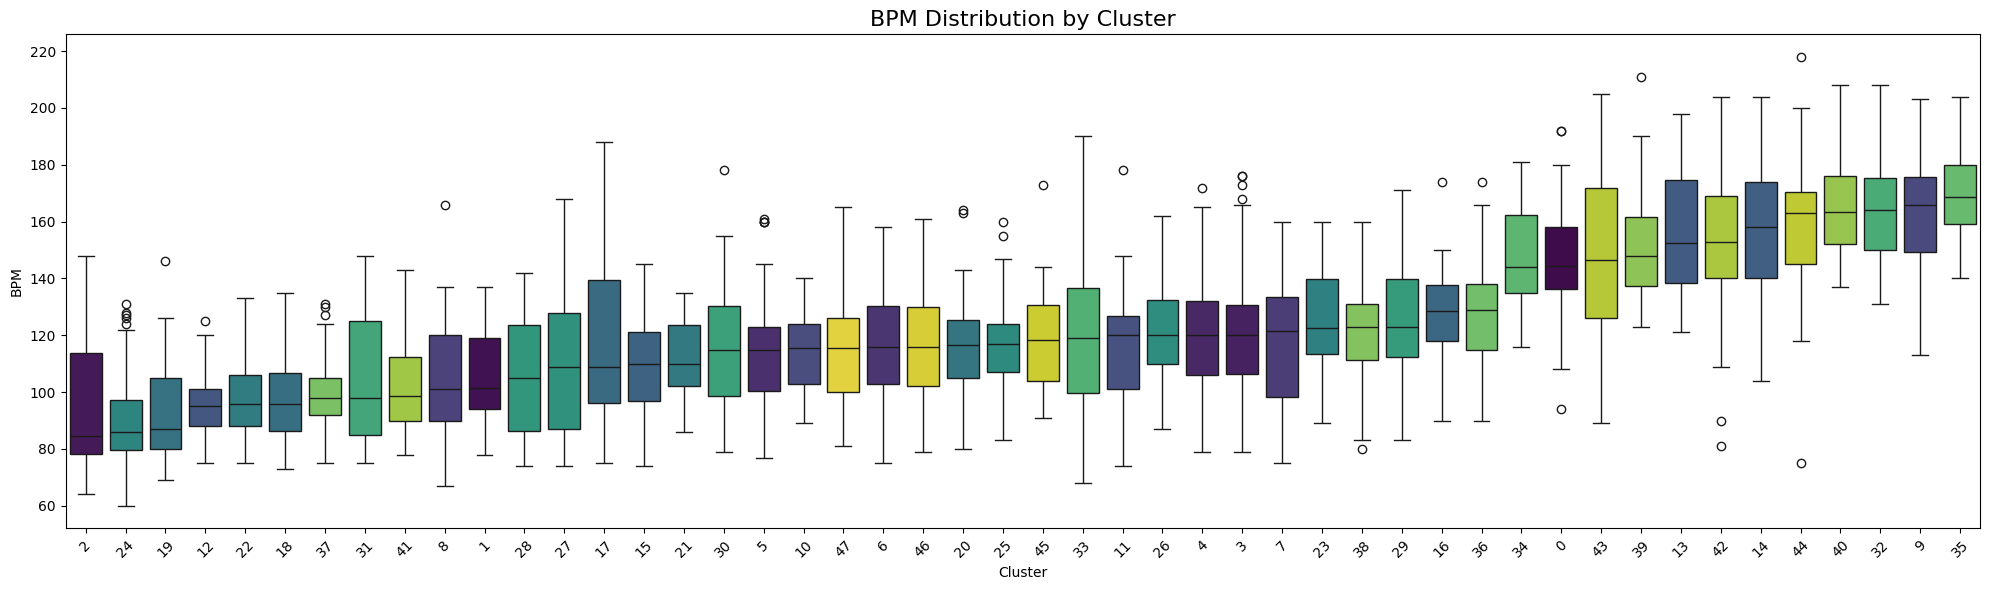

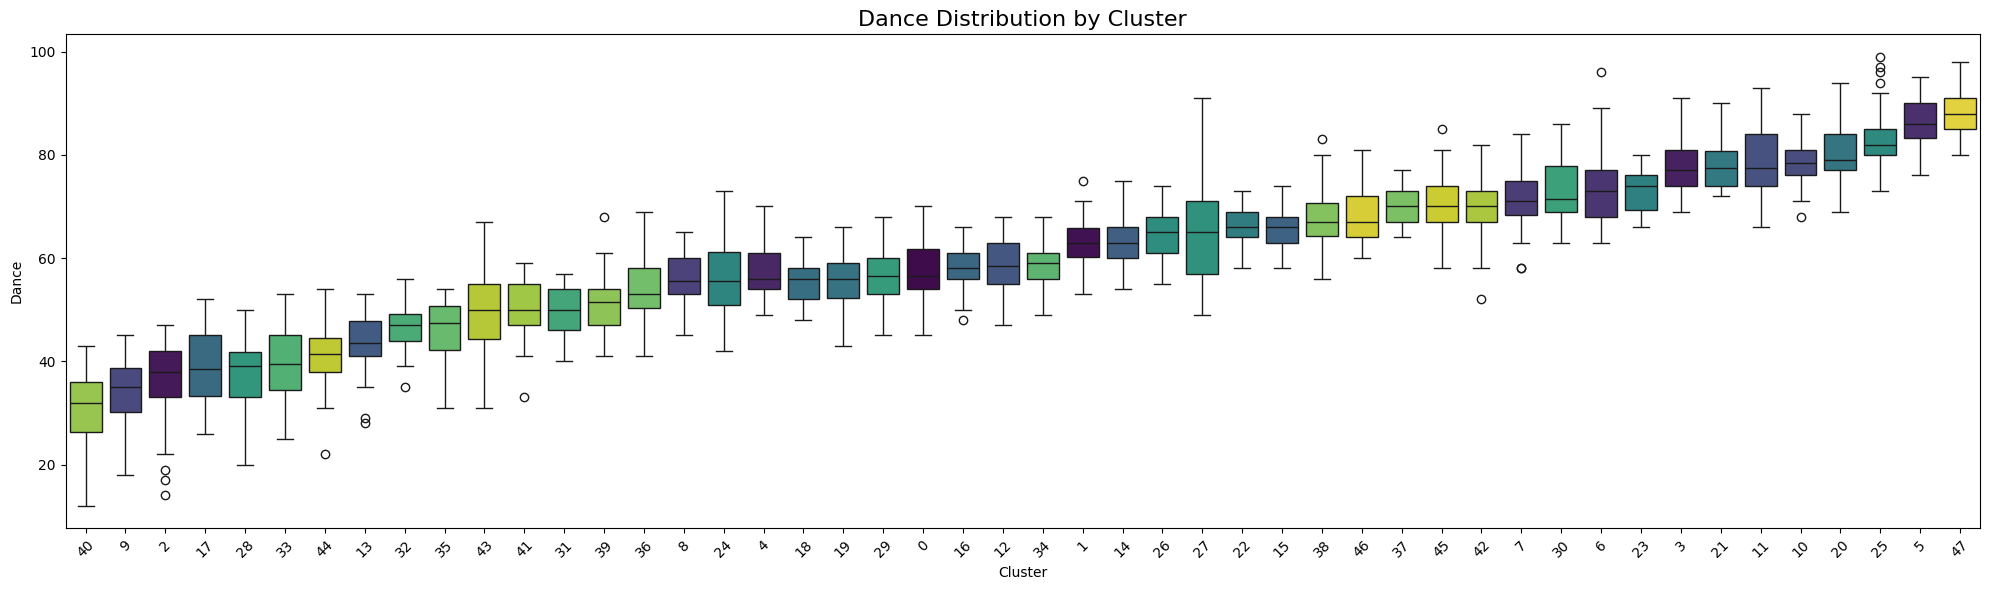

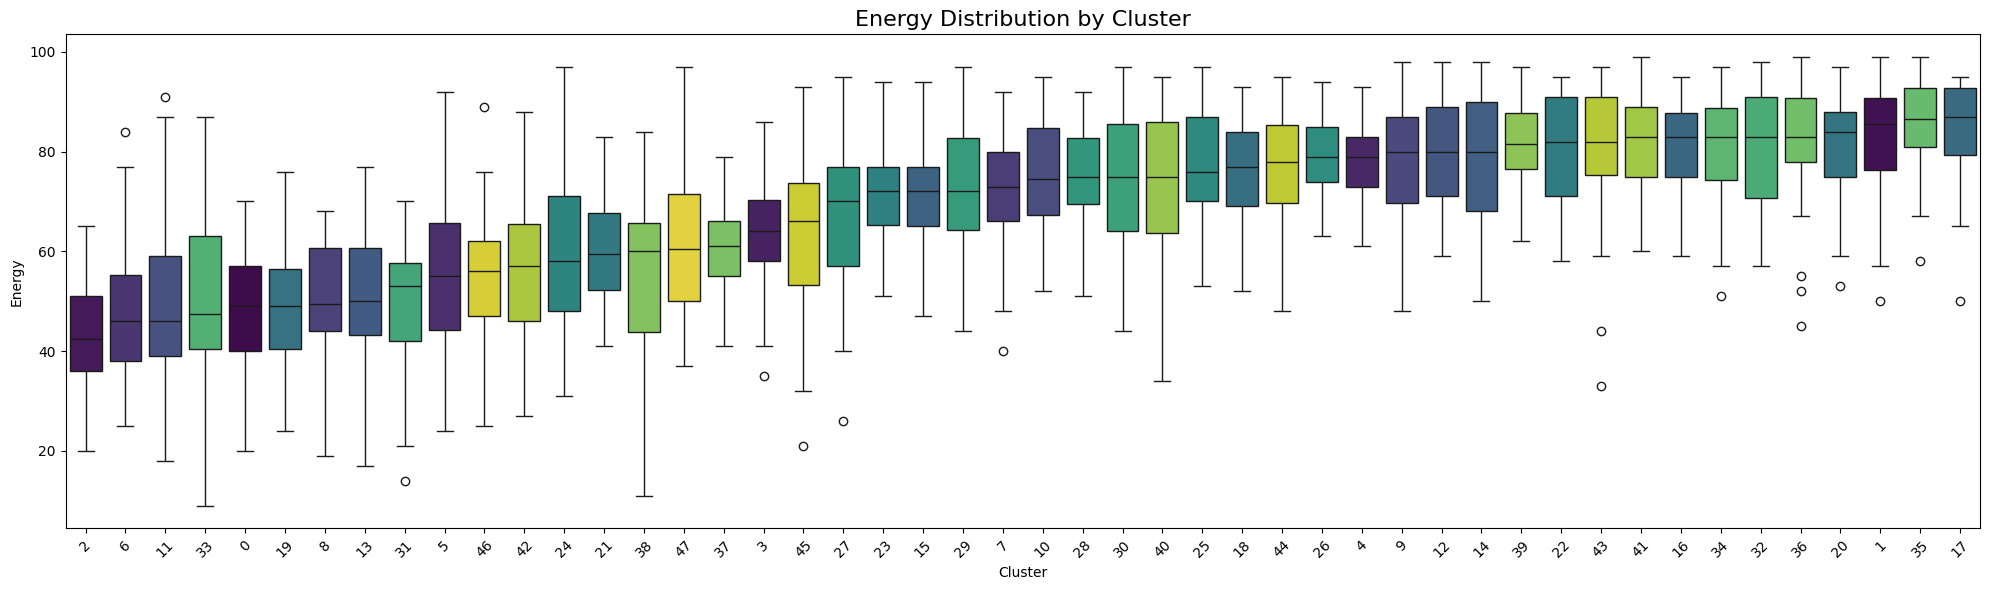

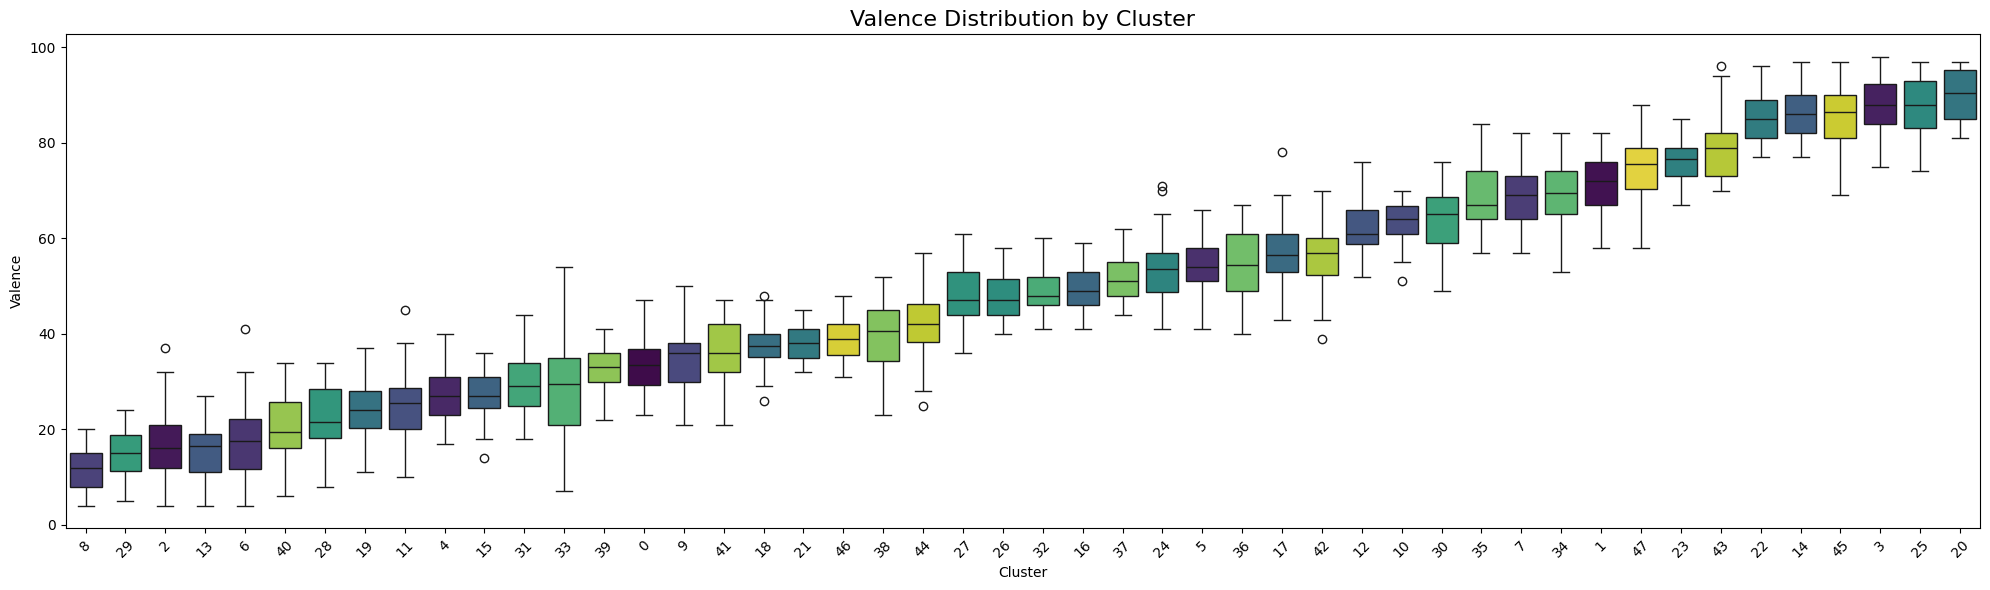

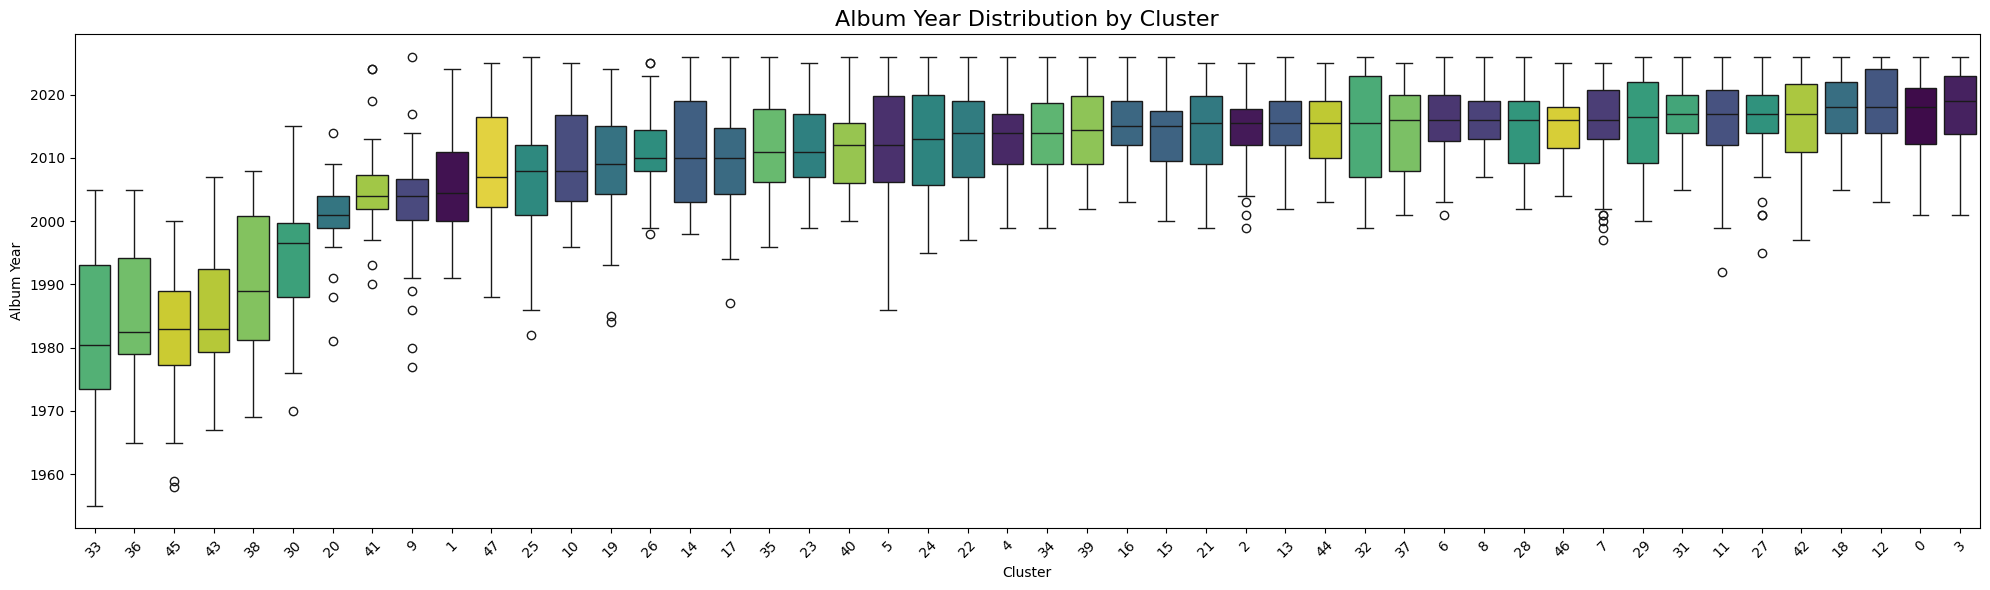

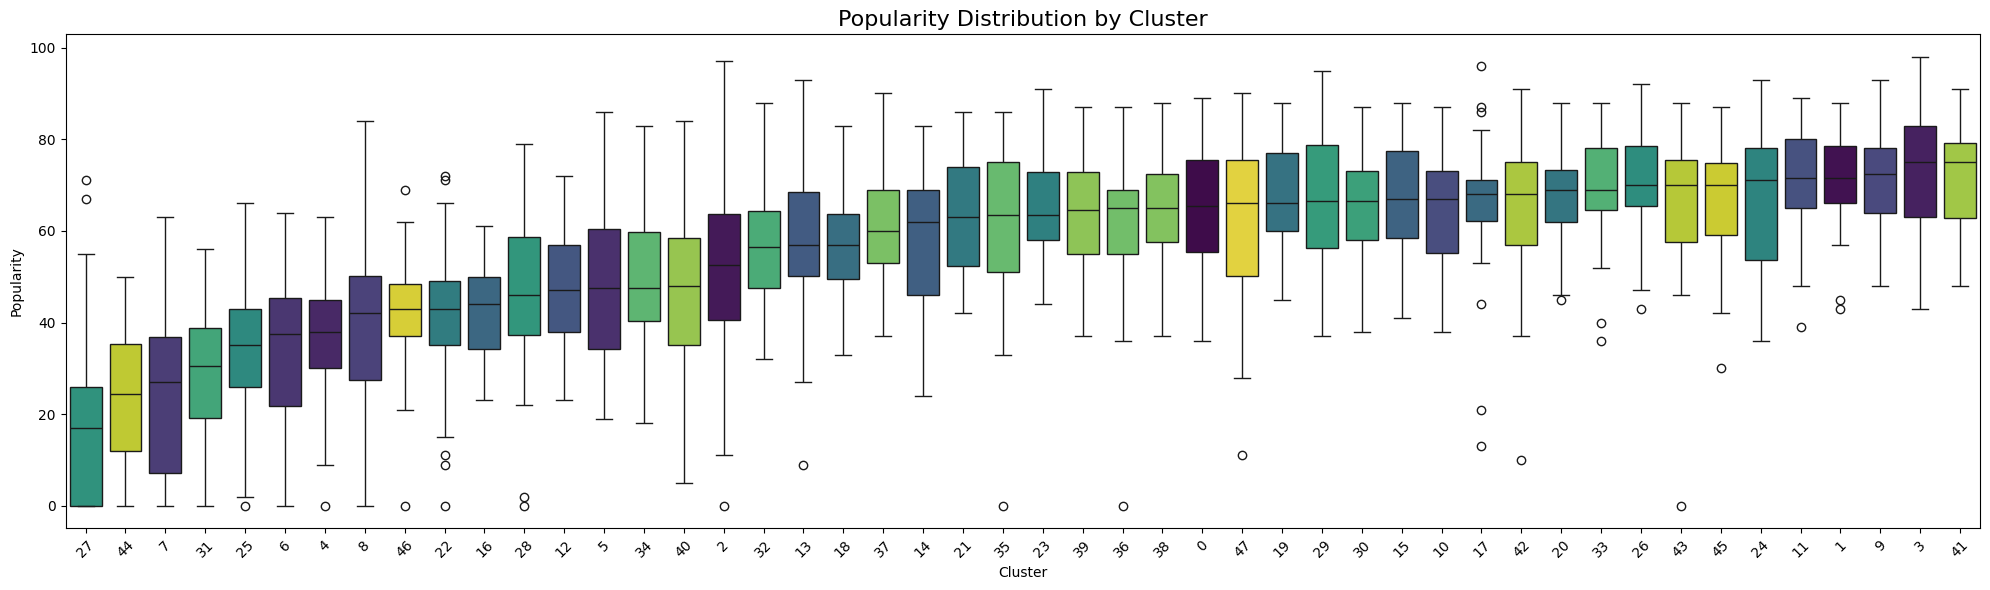

In [10]:
def plot_feature_by_cluster(df, feature, sort_by_median=True):
    plt.figure(figsize=(20, 6))
    order = df.groupby('Cluster')[feature].median().sort_values().index if sort_by_median else None
    sns.boxplot(
        x='Cluster', 
        y=feature, 
        data=df, 
        order=order, 
        hue='Cluster',
        palette='viridis',
        legend=False
    )
    plt.xlabel('Cluster')
    plt.ylabel(feature)
    plt.title(f'{feature} Distribution by Cluster', fontsize=16)
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

# Then call it for any feature
plot_feature_by_cluster(df_playlists_spotify_api, 'BPM')
plot_feature_by_cluster(df_playlists_spotify_api, 'Dance')
plot_feature_by_cluster(df_playlists_spotify_api, 'Energy')
plot_feature_by_cluster(df_playlists_spotify_api, 'Valence')
plot_feature_by_cluster(df_playlists_spotify_api, 'Album Year')
plot_feature_by_cluster(df_playlists_spotify_api, 'Popularity')


In [11]:
def plot_multiple_clusters(df, cluster_ids, features=None, cols=2):
    if features is None:
        features = FEATURES
    
    rows = (len(cluster_ids) + cols - 1) // cols  # Ceiling division
    fig, axes = plt.subplots(rows, cols, figsize=(7 * cols, 5 * rows))
    axes = axes.flatten() if len(cluster_ids) > 1 else [axes]
    
    for i, (ax, cluster_id) in enumerate(zip(axes, cluster_ids)):
        cluster_data = df[df['Cluster'] == cluster_id][features].copy()
        
        for f in features:
            cluster_data[f] = (cluster_data[f] - df[f].mean()) / df[f].std()
        
        melted = cluster_data.melt(var_name='Feature', value_name='Z-Score')
        
        sns.boxplot(
            x='Feature',
            y='Z-Score',
            data=melted,
            hue='Feature',
            palette='viridis',
            legend=False,
            ax=ax
        )
        ax.axhline(0, color='gray', linestyle='--', alpha=0.5)
        ax.set_title(f'Cluster {cluster_id} (n={len(cluster_data)})')
        ax.set_xlabel('')
        ax.tick_params(axis='x', rotation=45)
    
    # Hide empty subplots if cluster count doesn't fill grid
    for ax in axes[len(cluster_ids):]:
        ax.set_visible(False)
    
    plt.tight_layout()
    plt.show()


#### Example: Clusters with Low Valence

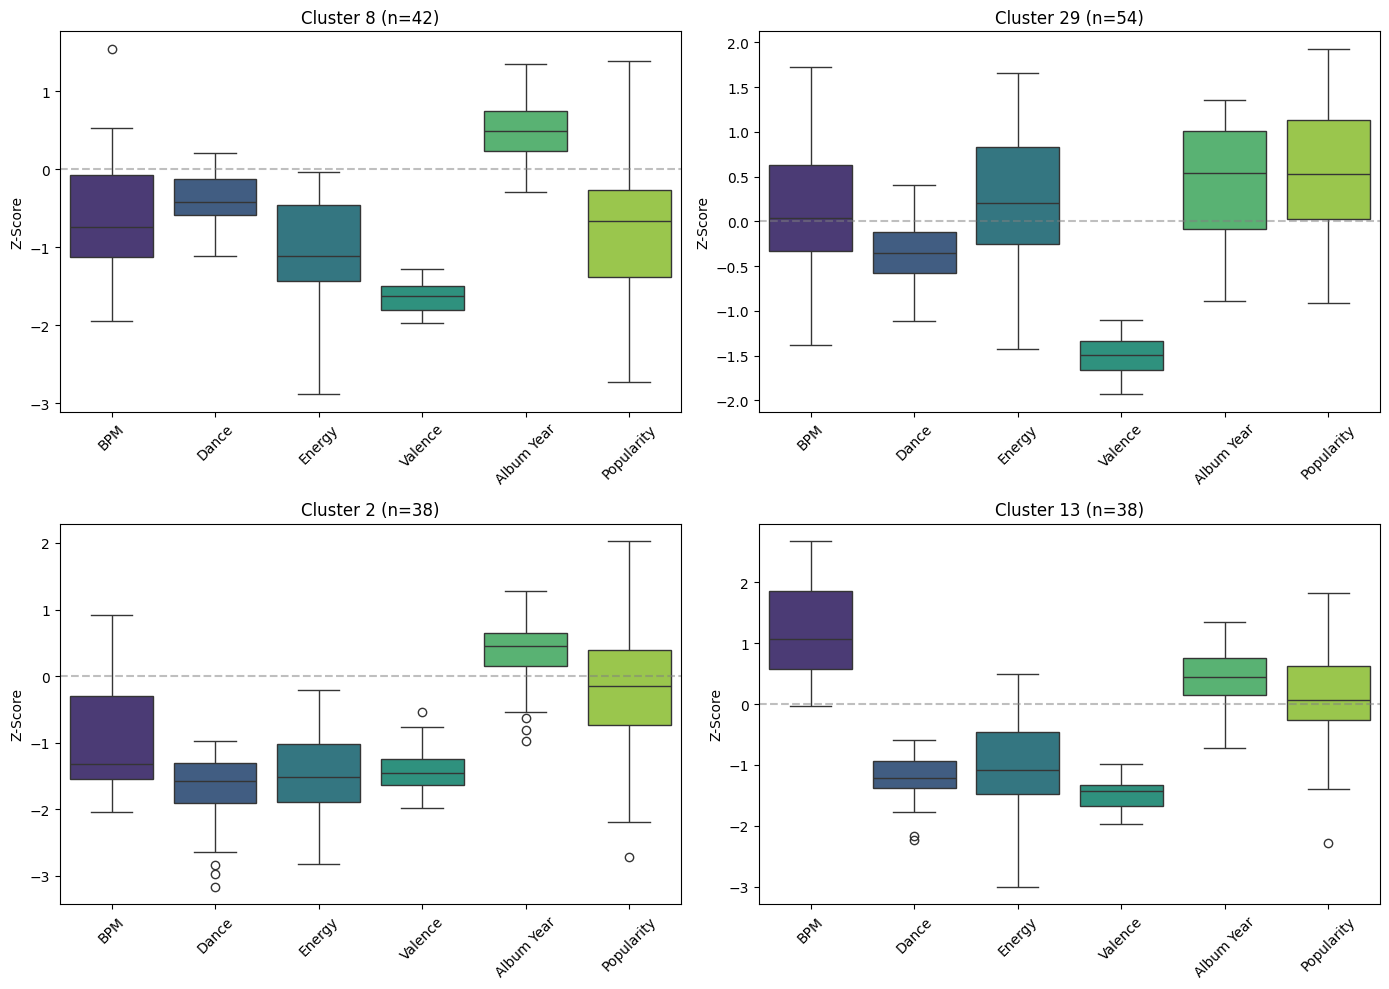

In [12]:
plot_multiple_clusters(df_playlists_spotify_api, cluster_ids=[8, 29, 2, 13], cols=2)

##### Songs in Each Cluster

In [13]:
df_cluster_8 = df_playlists_spotify_api[df_playlists_spotify_api['Cluster'] == 8][['Song', 'Artist']]
df_cluster_29 = df_playlists_spotify_api[df_playlists_spotify_api['Cluster'] == 29][['Song', 'Artist']]
df_cluster_2 = df_playlists_spotify_api[df_playlists_spotify_api['Cluster'] == 2][['Song', 'Artist']]
df_cluster_13 = df_playlists_spotify_api[df_playlists_spotify_api['Cluster'] == 13][['Song', 'Artist']]

In [14]:
df_cluster_8.head(10)

,Song,Artist
395,Werewolf,CocoRosie
396,Light A Fire,Gavin Adcock
397,HIGHEST IN THE ROOM,Travis Scott
398,Last Night of Our Lives,Vertical Horizon
399,Jealous Sea,MEG MYERS
400,Tell Me The Truth,Two Feet
401,Alcatraz,Oliver Riot
402,Better for It,Foreign Air
403,Hey Now,Augustana
404,love me,Ex Habit


In [15]:
df_cluster_29.head(10)

,Song,Artist
1437,The Reason,Hoobastank
1438,Nevermind,Dennis Lloyd
1439,Howling At The Moon,Phantogram
1440,Get Low,"Lil Jon & The East Side Boyz,Ying Yang Twins"
1441,Ways to Go,GROUPLOVE
1442,Chasing Cars,Snow Patrol
1443,Apartment,BOBI ANDONOV
1444,Tití Me Preguntó,Bad Bunny
1445,Running Up That Hill (From The 'Stranger Thing...,Baltic House Orchestra
1446,After Hours,The Weeknd


In [16]:
df_cluster_2.head(10)

,Song,Artist
100,EoO,Bad Bunny
101,The Silence,Manchester Orchestra
102,PRBLMS,6LACK
103,Kill Our Way to Heaven,Michl
104,High For This,The Weeknd
105,Flesh and Bone,Black Math
106,Skyfall,Adele
107,Cravin',"Stileto,Kendyle Paige"
108,The Lightning Strike (What If This Storm Ends?),Snow Patrol
109,Medicine,Daughter


In [17]:
df_cluster_13.head(10)

,Song,Artist
647,Hide and Seek,Imogen Heap
648,Open (Passionate),Kehlani
649,Die Trying,Michl
650,wet dreams,Artemas
651,Shameless,Camila Cabello
652,Entombed,Deftones
653,Hollywood's Bleeding,Post Malone
654,Incomplete,Backstreet Boys
655,Doing the Right Thing,Daughter
656,A Rush of Blood to the Head,Coldplay


#### Example: Clusters with High Valence

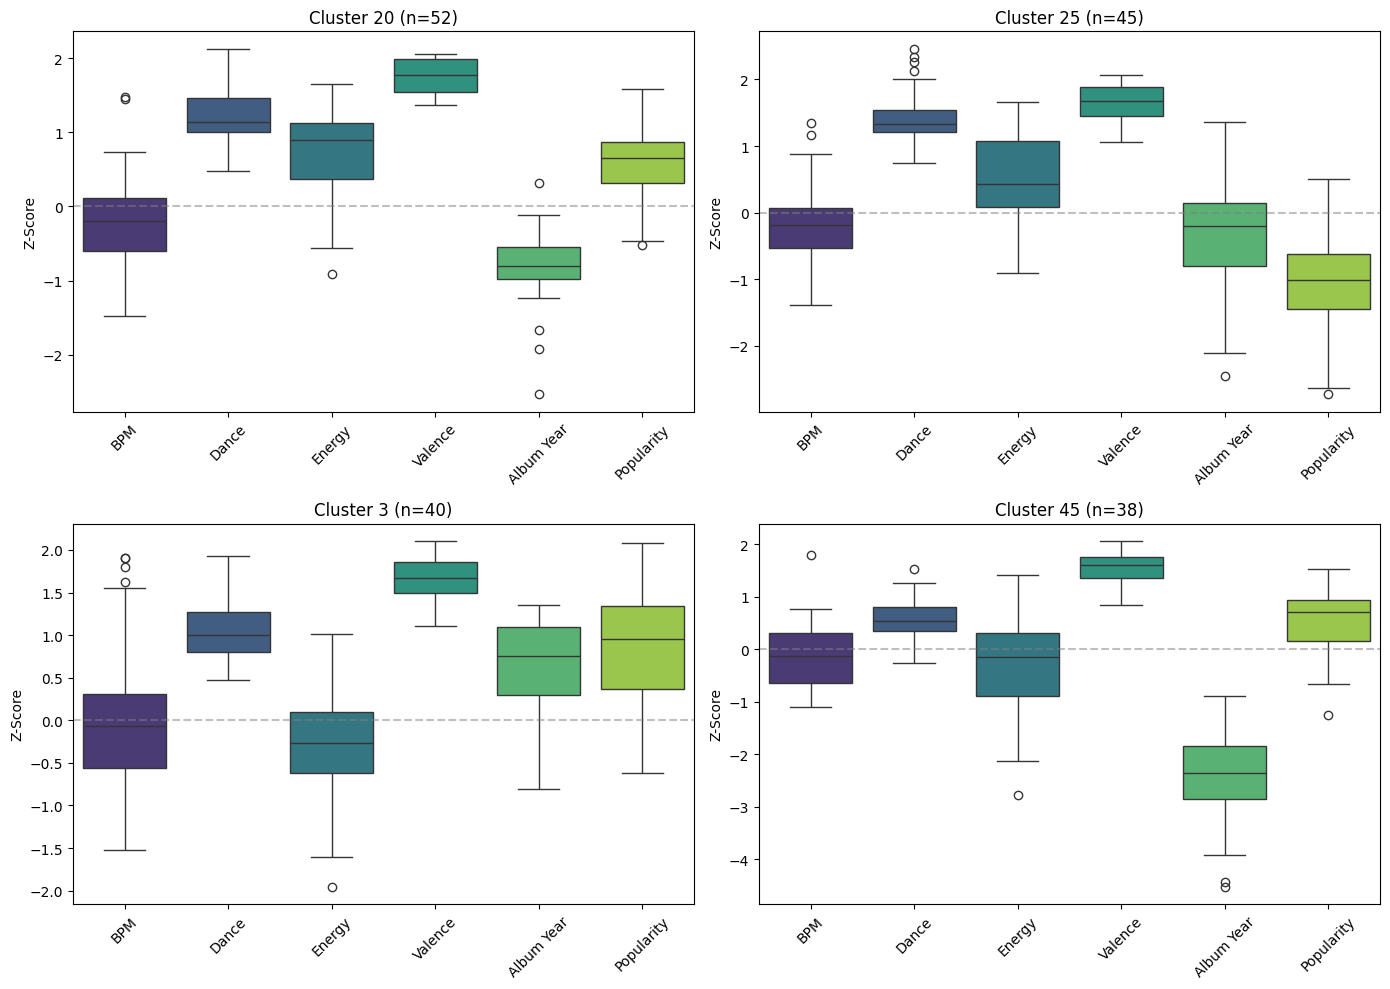

In [18]:
plot_multiple_clusters(df_playlists_spotify_api, cluster_ids=[20, 25, 3, 45], cols=2)

##### Songs in each cluster

In [19]:
df_cluster_20 = df_playlists_spotify_api[df_playlists_spotify_api['Cluster'] == 20][['Song', 'Artist']]
df_cluster_25 = df_playlists_spotify_api[df_playlists_spotify_api['Cluster'] == 25][['Song', 'Artist']]
df_cluster_3 = df_playlists_spotify_api[df_playlists_spotify_api['Cluster'] == 3][['Song', 'Artist']]
df_cluster_45 = df_playlists_spotify_api[df_playlists_spotify_api['Cluster'] == 45][['Song', 'Artist']]

In [20]:
df_cluster_20.head(10)

,Song,Artist
973,Church (feat. Teddy Verseti),"T-Pain,Teddy Verseti"
974,Bad Girl,USHER
975,Right Thurr,Chingy
976,...Baby One More Time,Britney Spears
977,Oops!...I Did It Again,Britney Spears
978,Meneaito (Original),Gaby
979,Quit Playing Games (With My Heart),Backstreet Boys
980,Jenny from the Block (feat. Jadakiss & Styles ...,"Jennifer Lopez,Jadakiss,Styles P"
981,The Fresh Prince of Bel-Air,DJ Jazzy Jeff & The Fresh Prince
982,Goodies (feat. Petey Pablo),"Ciara,Petey Pablo"


In [21]:
df_cluster_25.head(10)

,Song,Artist
1242,Hot Like Fire (Timbaland's Groove Mix) [feat. ...,"Aaliyah,Missy Elliott,Timbaland"
1243,Parents Just Don't Understand,DJ Jazzy Jeff & The Fresh Prince
1244,It's Like That,"Mariah Carey,Jermaine Dupri,Fatman Scoop"
1245,Shape of You,Ed Sheeran
1246,Whole New Way,Scissor Sisters
1247,High On Your Love,K7
1248,Mudfootball (For Moe Lerner),Jack Johnson
1249,Money Ain't A Thang,"JAŸ-Z,Jermaine Dupri"
1250,MAD GAAL,BEAM
1251,Put the Gun Down,ZZ Ward


In [22]:
df_cluster_3.head(10)

,Song,Artist
138,Feel It Still,Portugal. The Man
139,White Keys,Dominic Fike
140,Slow Hands,Niall Horan
141,Family Affair,Mary J. Blige
142,Don't,Ed Sheeran
143,Sensational (feat. Davido & Lojay),"Chris Brown,Davido,Lojay"
144,Attention,Charlie Puth
145,Kangaroo Court,Capital Cities
146,Dangerous,"Big Data,Joywave"
147,Stayin Alive x In Da Club (Mashup),"Antifarox,DJ Kuff"


In [23]:
df_cluster_45.head(10)

,Song,Artist
2158,The Stroke - Remastered 2010,Billy Squier
2159,Love Is A Battlefield,Pat Benatar
2160,I Want You to Want Me,Cheap Trick
2161,Heartbreak Hotel,Elvis Presley
2162,No Sleep Till Brooklyn,Beastie Boys
2163,Casey Jones - 2013 Remaster,Grateful Dead
2164,Fantasy,Mariah Carey
2165,Same Old Song And Dance - 1998 Digital Remaster,Frank Sinatra
2166,Don't Want You Back,Backstreet Boys
2167,The Best,Tina Turner
